# Notebook for making illustrative papers for the article

In [31]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
import cmap



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()



In [32]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"
    SLIDES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/presentation_figures"


else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


## Defining functions

In [33]:
def sigmoid(x, s=1.0, loc=0.0):
    return 1 / (1 + jnp.exp(-(x - loc)/s))

def exp_state(x, s=1.0, loc=0.0):
    return 2*sigmoid(x, s=s, loc=loc) - 1

def gaussian(x, mu=0.0, sigma=1.0, nf=1.0):
    return nf * jnp.exp(-0.5 * ((x - mu) / sigma) ** 2) #(1 / (sigma * jnp.sqrt(2 * jnp.pi))) * jnp.exp(-0.5 * ((x - mu) / sigma) ** 2)

## Illustrative figure for sigmoid

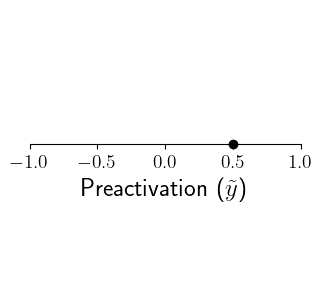

In [5]:
# simple number scale with 
x_input = 0.5
fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.plot([x_input], [0], marker='o', color='k')
ax.spines['bottom'].set_position('zero')


ax.set_yticklabels([])

# remove the ticks on y axis
ax.set_yticks([])

ax.tick_params(axis='both', which='major', labelsize=14)

ax.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=18)

sns.despine(top=True, right=True, left=True)

# pre_ill = f"preactivation_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, pre_ill), transparent=True, dpi=300, bbox_inches="tight")

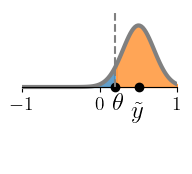

In [ ]:
# Gaussian and threshold over 
t = jnp.linspace(-1, 1, 100)
gauss_ = gaussian(t, mu=x_input, sigma=0.2, nf=0.8)

th_ = 0.2

fig, ax = plt.subplots(figsize=(2, 2))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.plot([x_input], [0], marker='o', color='k')
ax.plot([th_], [0], marker='o', color='k')
ax.plot(t, gauss_, color='0.5', lw=3)
ax.text(th_*0.8, -0.3, r"$\theta$", fontsize=18)
ax.text(x_input*0.8, -0.4, r"$\tilde{y}$", fontsize=18)
ax.spines['bottom'].set_position('zero')

# fill between gauss and x axis
ax.fill_between(t, gauss_, 0, where=(t > th_), color='C1', alpha=0.7)
ax.fill_between(t, gauss_, 0, where=(t <= th_), color='C0', alpha=0.7)

ax.vlines(th_, ymin=0, ymax=1.0, color="0.5", lw=1.5, ls="--")

ax.set_yticklabels([])

# remove the ticks on y axis
ax.set_yticks([])

ax.tick_params(axis='both', which='major', labelsize=14)

sns.despine(top=True, right=True, left=True)

# dist_ill = f"distribution_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, dist_ill), transparent=True, dpi=300, bbox_inches="tight")

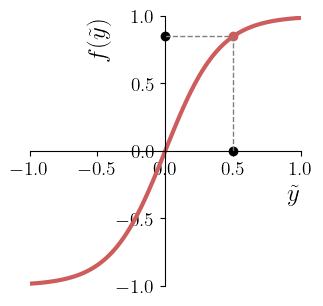

In [ ]:
# deterministic mapping
act_ = exp_state(x_input, s=0.2)
t = jnp.linspace(-1, 1, 100)
sigmoid_ = exp_state(t, s=0.2)

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.plot(t, sigmoid_, color='indianred', lw=3)
ax.plot([x_input], [0], marker='o', color='k')
ax.plot([0], [act_], marker='o', color='k')
ax.plot([x_input], [act_], marker='o', color='indianred')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')

# ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 0, "<k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 0, "vk", transform=ax.get_xaxis_transform(), clip_on=False, markersize=10)

ax.vlines(x=x_input, ymin=0, ymax=act_, color="0.5", lw=1.0, ls="--")
ax.hlines(y=act_, xmin=0, xmax=x_input, color="0.5", lw=1.0, ls="--")

ax.tick_params(axis='both', which='major', labelsize=14)


ax.set_xlabel(r"$\tilde{y}$", fontsize=18, loc='right')
ax.set_ylabel(r"$f(\tilde{y})$", fontsize=18, loc='top')

sns.despine(top=True, right=True)

# sig_ill = f"sigmoid_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, sig_ill), transparent=True, dpi=300, bbox_inches="tight")

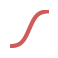

In [ ]:
## Generic sigmoid without the axes!
# deterministic mapping
act_ = exp_state(x_input, s=0.2)
t = jnp.linspace(-1, 1, 100)
sigmoid_ = exp_state(t, s=0.2)

fig, ax = plt.subplots(figsize=(0.5, 0.5))
ax.set_xlim(-1, 1)
# ax.set_ylim(-1, 1)
ax.plot(t, sigmoid_, color='indianred', lw=3)
# ax.plot([x_input], [0], marker='o', color='k')
# ax.plot([0], [act_], marker='o', color='k')
# ax.plot([x_input], [act_], marker='o', color='indianred')
ax.axis('off')
# ax.spines['bottom'].set_position('zero')
# ax.spines['left'].set_position('zero')

# ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 0, "<k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 0, "vk", transform=ax.get_xaxis_transform(), clip_on=False, markersize=10)

# ax.vlines(x=x_input, ymin=0, ymax=act_, color="0.5", lw=1.0, ls="--")
# ax.hlines(y=act_, xmin=0, xmax=x_input, color="0.5", lw=1.0, ls="--")

# ax.tick_params(axis='both', which='major', labelsize=14)


# ax.set_xlabel(r"$\tilde{y}$", fontsize=18, loc='right')
# ax.set_ylabel(r"$f(\tilde{y})$", fontsize=18, loc='top')

sns.despine(top=True, right=True)

generic_sig_ill = f"generic_sigmoid_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, generic_sig_ill), transparent=True, dpi=300, bbox_inches="tight")

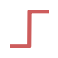

In [ ]:
## generic heaviside
# deterministic mapping
act_ = exp_state(x_input, s=0.2)
t = jnp.linspace(-1, 1, 100)
h_ = jnp.heaviside(t, 0)

fig, ax = plt.subplots(figsize=(0.5, 0.5))
# ax.set_xlim(-1, 1)
# ax.set_ylim(-1, 1)
ax.plot(t, h_, color='indianred', lw=3)
# ax.plot([x_input], [0], marker='o', color='k')
# ax.plot([0], [act_], marker='o', color='k')
# ax.plot([x_input], [act_], marker='o', color='indianred')
ax.axis('off')
# ax.spines['bottom'].set_position('zero')
# ax.spines['left'].set_position('zero')

# ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 0, "<k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 0, "vk", transform=ax.get_xaxis_transform(), clip_on=False, markersize=10)

# ax.vlines(x=x_input, ymin=0, ymax=act_, color="0.5", lw=1.0, ls="--")
# ax.hlines(y=act_, xmin=0, xmax=x_input, color="0.5", lw=1.0, ls="--")

# ax.tick_params(axis='both', which='major', labelsize=14)


# ax.set_xlabel(r"$\tilde{y}$", fontsize=18, loc='right')
# ax.set_ylabel(r"$f(\tilde{y})$", fontsize=18, loc='top')

sns.despine(top=True, right=True)

# generic_h_ill = f"generic_heaviside_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, generic_h_ill), transparent=True, dpi=300, bbox_inches="tight")

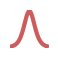

In [30]:
# gradient function: cartoon!
t = jnp.linspace(-1, 1, 100)
grad_ = 2*sigmoid(t, s=0.2)*(1 - sigmoid(t, s=0.2))
grad_pt = 2*sigmoid(x_input, s=0.2)*(1 - sigmoid(x_input, s=5))

fig, ax = plt.subplots(figsize=(0.5, 0.5))
# ax.set_xlim(-1, 1)
# ax.set_ylim(-1, 1)
ax.plot(t, grad_, color='indianred', lw=3)
# ax.plot([x_input], [0], marker='o', color='k')
# ax.plot([x_input], [grad_pt], marker='o', color='indianred')
# ax.plot([0], [grad_pt], marker='o', color='k')
# ax.spines['bottom'].set_position('zero')
# ax.spines['left'].set_position('zero')
ax.axis("off")

# ax.vlines(x=x_input, ymin=0, ymax=grad_pt, color="0.5", lw=1.0, ls="--")
# ax.hlines(y=grad_pt, xmin=0, xmax=x_input, color="0.5", lw=1.0, ls="--")

# ax.tick_params(axis='both', which='major', labelsize=14)


# ax.set_xlabel(r"$\tilde{y}$", fontsize=18, loc='right')
# ax.set_ylabel(r"$f^\prime(\tilde{y})$", fontsize=18, loc='top')

sns.despine(top=True, right=True)

grad_cartoon = f"gradient_cartoon{today}.pdf"
fig.savefig(os.path.join(FIGURES_PATH, grad_cartoon), transparent=True, dpi=300, bbox_inches="tight")

Samples: [ 1 -1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1]


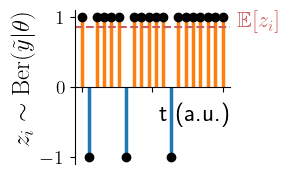

In [ ]:
## sampling from distribution
key = jax.random.key(4534)
nu_ = 20
samples_ = jax.random.bernoulli(key, p=act_, shape=(nu_,)).astype(int)
samples_ = 2*samples_ - 1
print(f"Samples: {samples_}")
colors_ = ["C1" if s == 1 else "C0" for s in samples_]

t = jnp.linspace(-1, 1, len(samples_))
sigmoid_ = exp_state(t, s=0.2)

fig, ax = plt.subplots(figsize=(2, 2))
ax.vlines(x=t, ymin=0, ymax=samples_, color=colors_, lw=2.5)
ax.plot(t, samples_, "o", markersize=6, color="k")
ax.axhline(y=act_, color="indianred", lw=1.5, ls="--")

ax.text(1.2, act_, r"$\mathbb{E}[z_i]$", fontsize=16, color="indianred")

ax.spines['bottom'].set_position('zero')
# ax.spines['left'].set_position('zero') 

ax.set_xticklabels([])

ax.tick_params(axis='both', which='major', labelsize=14)

# ax.set_xlim(-1, 1)
ax.set_ylim(-1.1, 1.1)

ax.set_xlabel(r"t (a.u.)", fontsize=18, loc='right')
ax.set_ylabel(r"$z_i \sim \textrm{Ber}(\tilde{y} \lvert \theta)$", fontsize=18, loc='top')

sns.despine(top=True, right=True)

# sam_ill = f"sampling_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, sam_ill), transparent=True, dpi=300, bbox_inches="tight")

## Illustrations for gradient

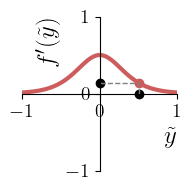

In [ ]:
# gradient function
t = jnp.linspace(-1, 1, 100)
grad_ = 2*sigmoid(t, s=0.2)*(1 - sigmoid(t, s=0.2))
grad_pt = 2*sigmoid(x_input, s=0.2)*(1 - sigmoid(x_input, s=0.2))

fig, ax = plt.subplots(figsize=(2, 2))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.plot(t, grad_, color='indianred', lw=3)
ax.plot([x_input], [0], marker='o', color='k')
ax.plot([x_input], [grad_pt], marker='o', color='indianred')
ax.plot([0], [grad_pt], marker='o', color='k')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')


ax.vlines(x=x_input, ymin=0, ymax=grad_pt, color="0.5", lw=1.0, ls="--")
ax.hlines(y=grad_pt, xmin=0, xmax=x_input, color="0.5", lw=1.0, ls="--")

ax.tick_params(axis='both', which='major', labelsize=14)


ax.set_xlabel(r"$\tilde{y}$", fontsize=18, loc='right')
ax.set_ylabel(r"$f^\prime(\tilde{y})$", fontsize=18, loc='top')

sns.despine(top=True, right=True)

grad_ill = f"gradient_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, grad_ill), transparent=True, dpi=300, bbox_inches="tight")

Samples: [ 1 -1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1]
Grad samples: [1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.], len: 19


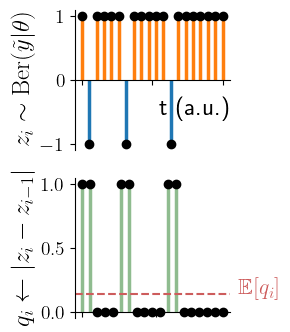

In [ ]:
## pairwise-sampling illustration
key = jax.random.key(4534)
nu_ = 20
samples_ = jax.random.bernoulli(key, p=act_, shape=(nu_,)).astype(int)
samples_ = 2*samples_ - 1
print(f"Samples: {samples_}")
colors_ = ["C1" if s == 1 else "C0" for s in samples_]

t = jnp.linspace(-1, 1, len(samples_))
sigmoid_ = exp_state(t, s=0.2)

fig, [ax, ax1] = plt.subplots(2, 1,figsize=(2, 4))
ax.vlines(x=t, ymin=0, ymax=samples_, color=colors_, lw=2.5)
ax.plot(t, samples_, "o", markersize=6, color="k")
# ax.axhline(y=act_, color="indianred", lw=1.5, ls="--")

# ax.text(1.2, act_, r"$\mathbb{E}[z_i]$", fontsize=16, color="indianred")

ax.spines['bottom'].set_position('zero')
# ax.spines['left'].set_position('zero') 

ax.set_xticklabels([])

ax.tick_params(axis='both', which='major', labelsize=14)

# ax.set_xlim(-1, 1)
ax.set_ylim(-1.1, 1.1)

ax.set_xlabel(r"t (a.u.)", fontsize=18, loc='right')
ax.set_ylabel(r"$z_i \sim \textrm{Ber}(\tilde{y} \lvert \theta)$", fontsize=18, loc='top')

# bottom panel: pairwise differences
grad_samples = jnp.diff(samples_)/2
grad_samples = jnp.abs(grad_samples)

print(f"Grad samples: {grad_samples}, len: {len(grad_samples)}")
ax1.vlines(x=t[:-1], ymin=0, ymax=grad_samples, color="darkseagreen", lw=2.5)
ax1.plot(t[:-1], grad_samples, "o", markersize=6, color="k")
ax1.spines['bottom'].set_position('zero')

ax1.set_xticklabels([])

ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_ylabel(r"$q_i \gets \lvert z_i - z_{i-1} \rvert$", fontsize=18)

ax1.axhline(y=grad_pt, color="indianred", lw=1.5, ls="--")
ax1.text(1.1, grad_pt, r"$\mathbb{E}[q_i]$", fontsize=16, color="indianred")

sns.despine(top=True, right=True)

grad_sam_ill = f"pairwise_sampling_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, grad_sam_ill), transparent=True, dpi=300, bbox_inches="tight")


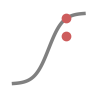

In [42]:
# deterministic mapping
act_hi = exp_state(x_input, s=0.2)
act_lo = exp_state(x_input*0.3, s=0.2)
t = jnp.linspace(-1, 1, 100)
sigmoid_ = exp_state(t, s=0.2)

fig, ax = plt.subplots(figsize=(1, 1))
# ax.set_xlim(-1, 1)
# ax.set_ylim(-1, 1)
ax.plot(t, sigmoid_, color='0.5', lw=2.5)
# ax.plot([x_input], [0], marker='o', color='k')
# ax.plot([0], [act_], marker='o', color='k')
ax.plot([x_input], [act_hi], marker='o', color='indianred')
ax.plot([x_input], [act_lo], marker='o', color='indianred')


# ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 0, "<k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=10)
# ax.plot(0, 0, "vk", transform=ax.get_xaxis_transform(), clip_on=False, markersize=10)

# ax.vlines(x=x_input, ymin=0, ymax=act_, color="0.5", lw=1.0, ls="--")
# ax.hlines(y=act_, xmin=0, xmax=x_input, color="0.5", lw=1.0, ls="--")

ax.tick_params(axis='both', which='major', labelsize=14)

ax.axis("off")



# ax.set_xlabel(r"$\tilde{y}$", fontsize=18, loc='right')
# ax.set_ylabel(r"$f(\tilde{y})$", fontsize=18, loc='top')

sns.despine(top=True, right=True)

# sig_ill = f"sigmoid_illustration_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, sig_ill), transparent=True, dpi=300, bbox_inches="tight")

## Softmax as noisy hardmax illustration